This notebook attempts to compare ordinary and MPS time evolution using the manually constructed MPOs.

The other method is to convert a dense time-step matrix into an MPO using `qtn.MatrixProductOperator.from_dense()`. However, for the case of using the LPE2 time evolution scheme, my laptop crashes around `n=15` from having to store such large matrices. 

In contrast, this method uses sparse matrices and manually constructs the MPO, avoiding the need to ever store a dense matrix. However, as shown in `mpo_construction_analysis.ipynb`, the manually constructed MPOs explode in bond dimension within the first few steps. As such, I can run this experiment up to `n=26`, but my laptop crashes around the 12th or 13th step.

Furthermore, since max MPS bond dimension hits my cap of 64 by the third step, further steps are likely already very inaccurate.

In [17]:
import importlib
import utils
importlib.reload(utils)

import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

In [18]:
ns = [5, 10, 15, 20, 25]  
steps = 10               # number of steps required for time evolution

def u(x):
    return np.sin(2*np.pi*2*x) + 0.5*np.sin(2*np.pi*7*x)

nu = 1e-3                 # diffusion coefficient 
save_every = 200          # after this many steps, take a snapshot of the function to plot on the graph
cfl = 0.1                 # controls time step relative to grid spacing. affects stability of time0-step scheme

# Set Up

In [19]:
times_op     = []
times_mps    = []
times_mpo    = []
times_ev_op  = []
times_ev_mps = [] 

for n in ns:
    N     = 2**n
    x     = np.linspace(0, 1, N, endpoint=False)
    dx    = x[1] - x[0] 
    dt    = cfl * dx*dx / nu 
    u0 = u(x)

    print("n = ", n)
    
    t = time.perf_counter()
    L = utils.laplacian(N, dx, "periodic", "sparse")
    A = utils.time_step(L, 1, dt, nu)
    t_op = time.perf_counter() - t

    t = time.perf_counter()
    mps0 = utils.vec_to_qtt_mps(u0, n)
    t_mps = time.perf_counter() - t

    t = time.perf_counter()
    mpoA = [utils.qtt_diffusion_mpo(n, cfl),]
    t_mpo = time.perf_counter() - t

    t = time.perf_counter()
    times, us, norms = utils.evolve_operator(u0, steps, A, dt)
    t_evolve_op = time.perf_counter() - t

    t = time.perf_counter()
    mps_saved, bond_track = utils.evolve_mps_timed(mps0, mpoA, steps)
    t_evolve_mps = time.perf_counter() - t

    print()


    times_op.append(t_op)
    times_mps.append(t_mps)
    times_mpo.append(t_mpo)
    times_ev_op.append(t_evolve_op)
    times_ev_mps.append(t_evolve_mps)


n =  5
step  0: 0.001386 s, max bond = 12
step  1: 0.002817 s, max bond = 36
step  2: 0.032608 s, max bond = 64
step  3: 0.113475 s, max bond = 64
step  4: 0.220904 s, max bond = 64
step  5: 0.287640 s, max bond = 64
step  6: 0.541309 s, max bond = 64
step  7: 1.655058 s, max bond = 64
step  8: 3.301021 s, max bond = 64
step  9: 12.051432 s, max bond = 64

n =  10
step  0: 0.002551 s, max bond = 13
step  1: 0.014264 s, max bond = 41
step  2: 0.242124 s, max bond = 64
step  3: 1.068917 s, max bond = 64
step  4: 1.090299 s, max bond = 64
step  5: 0.552691 s, max bond = 64
step  6: 1.010107 s, max bond = 64
step  7: 1.841212 s, max bond = 64
step  8: 3.646363 s, max bond = 64
step  9: 10.248287 s, max bond = 64

n =  15
step  0: 0.005063 s, max bond = 12
step  1: 0.006730 s, max bond = 36
step  2: 0.086565 s, max bond = 64
step  3: 0.339846 s, max bond = 64
step  4: 0.551339 s, max bond = 64
step  5: 0.586929 s, max bond = 64
step  6: 0.971476 s, max bond = 64
step  7: 1.911011 s, max bon

Timing comparison (evolution over 10 time steps)

 n  N = 2^n  setup (Op)  setup (MPS)  setup (MPO)  setup (TN total)  evol (Op)  evol (TN)  speedup (evol)
 5       32     0.20702      0.00041      0.00189           0.00231    0.02549   18.21685         0.00140
10     1024     0.00105      0.00124      0.00876           0.01000    0.00041   19.72797         0.00002
15    32768     0.00223      0.00319      0.00370           0.00689    0.01141   18.48369         0.00062
20  1048576     0.09509      0.13755      0.01698           0.15452    0.07722   21.91295         0.00352
25 33554432     5.19665      4.59233      0.00730           4.59962    0.88161   20.58909         0.04282


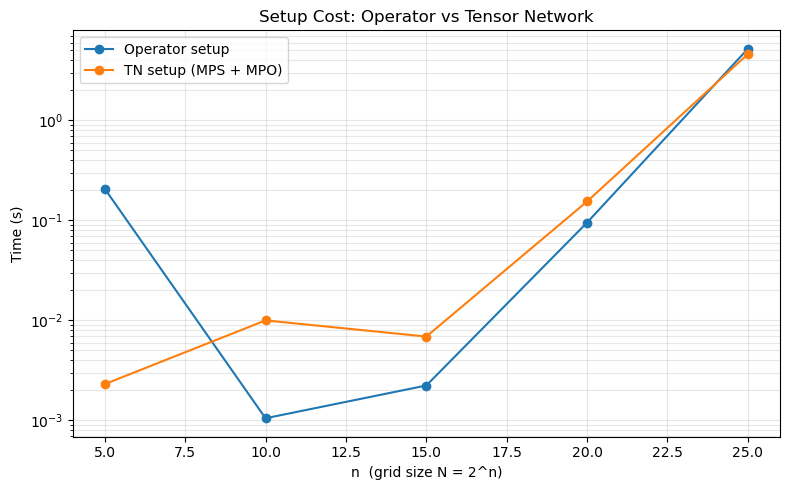

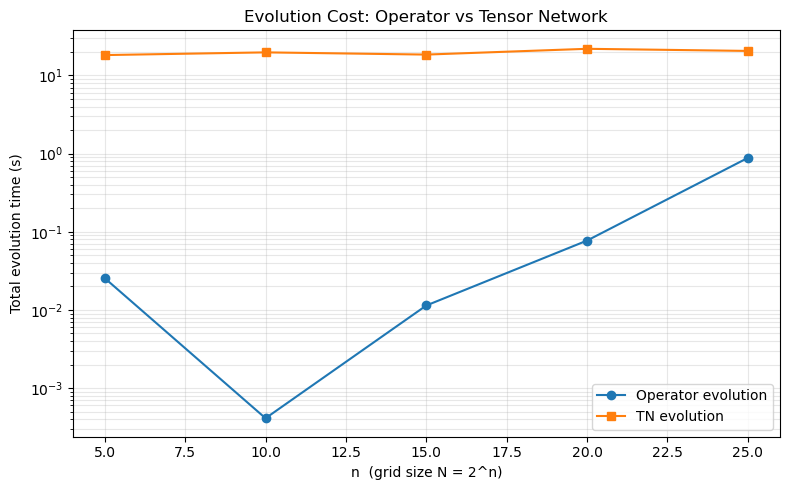

In [20]:
# ======================
# RAW NUMBERS COMPARISON
# ======================

N_vals = [2**n for n in ns]

print(f"Timing comparison (evolution over {steps} time steps)\n")
df = pd.DataFrame({
    "n": ns,
    "N = 2^n": N_vals,
    "setup (Op)": times_op,
    "setup (MPS)": times_mps,
    "setup (MPO)": times_mpo,
    "setup (TN total)": [m + p for m, p in zip(times_mps, times_mpo)],
    "evol (Op)": times_ev_op,
    "evol (TN)": times_ev_mps,
})
df["speedup (evol)"] = df["evol (Op)"] / df["evol (TN)"]
df = df.round(5)
print(df.to_string(index=False))



# ==============================
# INITIALISATION TIME COMPARISON
# ==============================

times_tn_setup = [m + p for m, p in zip(times_mps, times_mpo)]

plt.figure(figsize=(8,5))
plt.plot(ns, times_op, "o-", label="Operator setup")
plt.plot(ns, times_tn_setup, "o-", label="TN setup (MPS + MPO)")
plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Time (s)")
plt.title("Setup Cost: Operator vs Tensor Network")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()



# =========================
# TIME EVOLUTION COMPARISON
# =========================

plt.figure(figsize=(8,5))

plt.plot(ns, times_ev_op, "o-", label="Operator evolution")
plt.plot(ns, times_ev_mps, "s-", label="TN evolution")

plt.yscale("log")
plt.xlabel("n  (grid size N = 2^n)")
plt.ylabel("Total evolution time (s)")
plt.title("Evolution Cost: Operator vs Tensor Network")

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Note: the graphs vary quite wildly with each run. If a better analysis is required, it would be better to calculate the average times across several runs.